# CELL-FM — Condensate Titration

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BoHuangLab/CELL-FM/blob/master/notebooks/condensate_titration.ipynb)

**CELL-FM** is a virtual microscopy model that bridges microscopy images and protein
sequences. This notebook runs one of its applications end to end: predicting how an
**intrinsically disordered peptide (IDP)** behaves as its concentration rises.

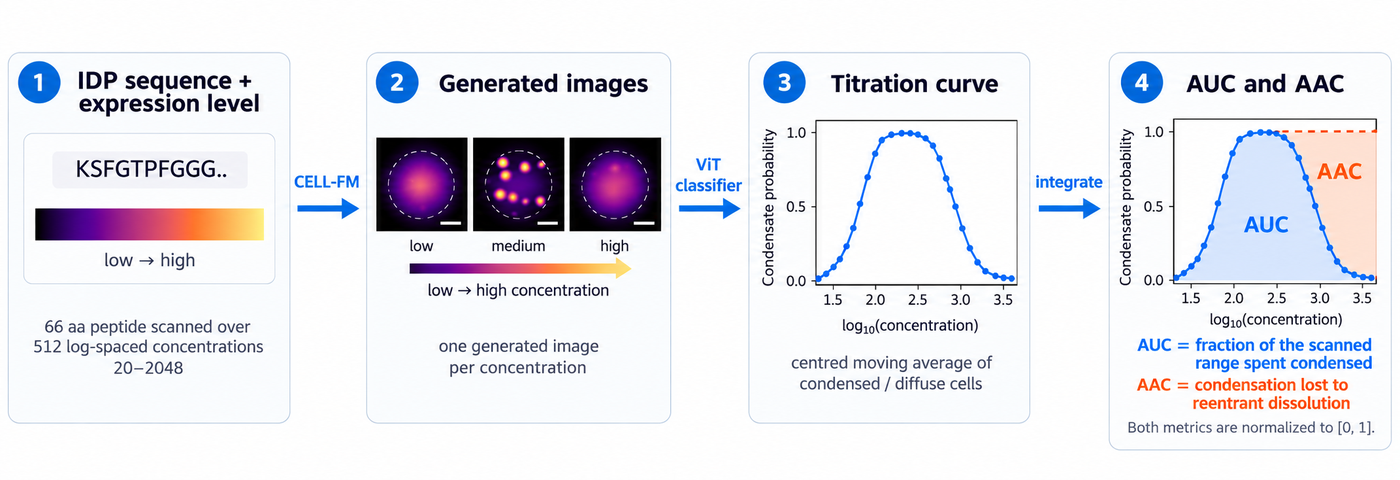

*The four stages, end to end. The diagram shows a 512-point ladder — the `standard`
preset below. The default is half that, and the published runs scan 4096.*

Give it a 66-residue sequence and three stages turn it into a number:

| Stage | What runs | Output |
| --- | --- | --- |
| **1 · Generate** | CELL-FM samples one microscopy image per protein-intensity level, along a log-spaced concentration ladder from 20 to 2048 a.u. | a stack of 2-channel 160×160 images |
| **2 · Classify** | a ViT calls each image **condensed** or **diffuse** | one binary call per image |
| **3 · Summarise** | a centred moving average over those calls is the **titration curve**; integrating it against log-intensity gives AUC and AAC | two numbers in [0, 1] |

**AUC** — the area *under* the titration curve: how much of the scanned concentration
range the sequence spends in the condensed state. Higher means it condenses more
readily, over a wider range of concentrations.

**AAC** — the area *above* it: condensation lost to **reentrant dissolution**. The curve
is compared against the one it would have followed had it never come back down
(everything past the maximum held flat), and AAC is the gap between the two. It is zero
when a sequence condenses and stays condensed, and grows the more it re-dissolves at
high concentration.

Both are normalised by the width of the log-intensity range, so both lie in [0, 1] and
are directly comparable between sequences.

---

**You need a GPU runtime.** *Runtime → Change runtime type → T4 GPU*; the free tier is
enough. Setup downloads about 4.4 GB of weights once, then each sequence takes a couple
of minutes at the default preset. On CPU everything still runs, but a single sequence
would take hours.

| | |
| --- | --- |
| Weights | [huggingface.co/BoHuangLab/CELL-FM](https://huggingface.co/BoHuangLab/CELL-FM) |
| Code | [github.com/BoHuangLab/CELL-FM](https://github.com/BoHuangLab/CELL-FM) |
| Hosted app | [huggingface.co/spaces/BoHuangLab/CELL-FM](https://huggingface.co/spaces/BoHuangLab/CELL-FM) |


## 1 · Setup

Four cells: check the runtime, install what Colab does not already ship, fetch the demo
code and weights, and build the models. Run them once, in order.


In [ ]:
import subprocess
import sys

print("python  ", sys.version.split()[0])
try:
    gpu = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        capture_output=True, text=True,
    ).stdout.strip()
except FileNotFoundError:
    gpu = ""
print("gpu     ", gpu if gpu else
      "NONE — Runtime > Change runtime type > T4 GPU, then rerun this cell")


In [ ]:
# Colab already ships torch, pandas and matplotlib; this adds the rest of the stack.
# Three choices below look odd and are deliberate:
#
#   --no-deps on esm   its metadata requires torchtext, which has no wheel past Python
#                      3.11 and would drag torch backwards. Nothing on the ESM-C code
#                      path imports it — the second line is what the import closure
#                      actually needs, esm's other bounds included.
#   "transformers<4.47"  esm's own bound, and it is behavioural rather than cosmetic.
#                      4.47 replaced the special-token properties on PreTrainedTokenizer
#                      with a _special_tokens_map served through __getattr__. esm 3.1.4's
#                      EsmSequenceTokenizer still expects the property, so on anything
#                      newer tokenizer.mask_token is None and generation dies inside
#                      esm/utils/encoding.py with "replace() argument 2 must be str, not
#                      None". 4.46.3 is the last release with the property, and it pulls
#                      tokenizers 0.20 and huggingface_hub 0.36, both of which have
#                      wheels for this Python.
#   "numpy<2"          esm 3.1.4 pins biotite==0.41.2, which needs NumPy 1.x and sits on
#                      the ESM-C import path: esm.utils.structure.protein_chain imports
#                      biotite.structure.io.npz, a module biotite deleted in 1.0. So the
#                      pin cannot be escaped by taking a newer biotite, and NumPy has to
#                      come down.
#   "pandas<3"         which drags this one with it. Most wheels built against NumPy 2
#                      still run under 1.x, but pandas 3 calls np.dtypes.StringDType, a
#                      NumPy 2 API that simply is not there in 1.x, so importing Colab's
#                      pandas under the pin dies with
#                      "module 'numpy.dtypes' has no attribute 'StringDType'".
#                      pandas 2.2.3 is the last release that works here, and it ships a
#                      wheel for this Python, so the pin costs nothing.
#   no flash-attn      without it ESM-C falls back to a pure-torch rotary embedding,
#                      verified to give identical results, and skips a CUDA build.
import sys

if sys.version_info >= (3, 13):
    print(f"Python {sys.version_info.major}.{sys.version_info.minor}: NumPy 1.x and "
          "biotite 0.41.2 have no wheels this new, so pip builds both from source.\n"
          "That works — it just makes this cell take a few minutes.\n")

%pip install -q --no-deps "esm==3.1.4"
%pip install -q "numpy<2" "pandas<3" "transformers<4.47" "diffusers==0.31.0" torchdiffeq loguru accelerate "biotite==0.41.2" biopython msgpack-numpy cloudpathlib tenacity brotli zstd attrs einops

import importlib.metadata as md

# pip prints two kinds of complaint above and neither is a failure:
#
#   "esm 3.1.4 requires torchtext"                       left unenforced on purpose:
#       nothing on the ESM-C code path imports it, and it has no wheel for this Python.
#       esm's transformers bound, by contrast, IS enforced above — it is real.
#   "<package> requires numpy>=2"                        Colab preinstalls opencv, jax,
#       shap and friends and none of them are imported here. A wheel compiled against
#       NumPy 2 still runs under 1.x, so most of those keep working anyway; what does
#       not survive is a package calling a NumPy 2 *Python* API, which is why pandas is
#       pinned above. If some other import ever dies on a missing numpy attribute, that
#       is the same problem and the same fix.
#
# What actually has to be true is checked below.
print("\nversions")
for pkg in ("torch", "numpy", "pandas", "transformers", "diffusers", "esm", "biotite"):
    try:
        print(f"  {pkg:14s} {md.version(pkg)}")
    except md.PackageNotFoundError:
        print(f"  {pkg:14s} MISSING")

def _below(pkg, major, minor):
    got = tuple(int(x) for x in md.version(pkg).split(".")[:2])
    return got < (major, minor)


ready = (md.version("numpy").startswith("1.")
         and md.version("pandas").startswith("2.")
         and md.version("biotite") == "0.41.2"
         and _below("transformers", 4, 47))
print("\nNumPy 1.x, pandas 2.x, biotite 0.41.2, transformers < 4.47:",
      "yes — the imports below will work" if ready else
      "NO — the next cell will fail; rerun this one")

# Colab imports NumPy at kernel start, so the downgrade only lands after a restart. That
# is expected here, not a crash: Colab reconnects on its own. When it does, carry on from
# the next cell — there is no need to rerun this one.
if "numpy" in sys.modules and sys.modules["numpy"].__version__ != md.version("numpy"):
    import os, time
    print(f"\nRestarting the kernel so NumPy {md.version('numpy')} takes effect — this is\n"
          "expected. Colab reconnects by itself; continue from the next cell.")
    time.sleep(1)
    os.kill(os.getpid(), 9)


In [ ]:
import os
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import snapshot_download

# The demo code lives in the public Space, so this notebook runs exactly what the hosted
# app runs: same model configs, same reference nucleus, same metrics. ~400 kB.
CODE = snapshot_download(repo_id="BoHuangLab/CELL-FM", repo_type="space")
sys.path.insert(0, CODE)

# NumPy 2 renamed trapz to trapezoid. metrics.py is written against NumPy 1, which the
# cell above installs; the alias only matters if that ever stops being true.
if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid

import metrics
import pipeline

print("code    ", CODE)
print("weights ", pipeline.MODEL_REPO)
print("device  ", pipeline.get_device())

# The NUP98 mutation panel travels with that snapshot: the wild type plus 91 sequences
# with 1 to 10 of its phenylalanines replaced by serine. Sections 2, 6 and 7 all draw on
# it, so it is loaded here with the rest of the demo's assets.
panel = pd.read_csv(os.path.join(CODE, "assets", "nup98_mutation_seqs.csv"), dtype=str)
sequences = dict(zip(panel.mutation, panel.sequence))

# One palette for every figure below: blue is the titration curve and the area under it,
# orange the area above it, aqua a sequence that passed validation in section 2.
CURVE, GAP, OTHER = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "font.size": 9,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
})


In [ ]:
# 2.1 GB of CELL-FM checkpoints, plus 2.3 GB for the ESM-C 600M protein encoder the
# generator is built around (fetched by the esm package the first time the model is
# constructed). Both are cached, so rerunning this cell is instant.
t0 = time.time()
pipeline.load_models()                                      # built on CPU, then moved
generator, classifier, tokenizer = pipeline.models_on(pipeline.get_device())

params = lambda m: sum(p.numel() for p in m.parameters()) / 1e6
print(f"generator   {params(generator):6.0f}M params   flow matching, ESM-C 600M encoder + image VAE")
print(f"classifier  {params(classifier):6.0f}M params   ViT, 2-channel 160x160 input")
print(f"\nready on {pipeline.get_device()} in {time.time() - t0:.0f}s")


## 2 · Choose a sequence

The input should be **66 amino acids**. That is not a convenience limit: all sequences in 
the CondenSeq library CELL-FM was trained on are 66-mers, so any other length is off-distribution.

The box below opens on the **NUP98 IDP** that ships with the demo. Type or paste your own
66-mer over it: it validates as you type, and whatever is valid in the box is what every
cell below runs. The dropdown loads a panel sequence into the box if you would rather
start from one of those.


In [ ]:
SEQUENCE = "KSFGTPFGGGTGGFGTTSTFGQNTGFGTTSGGAFGTSAFGSSNNTGGLFGNSQTKPGGLFGTSSFS"  # NUP98 IDP

sequence = pipeline.clean_sequence(SEQUENCE)
name = "WT"


def _name_of(seq):
    """Panel sequences keep their panel name, so a run of one is not repeated later."""
    return next((m for m, s in sequences.items() if s == seq), "custom")


def _commit(_=None):
    """Validate what is in the box and hand it to the rest of the notebook.

    pipeline.clean_sequence is the same check the model applies, so the box refuses
    exactly what the model would refuse, and says so before anything is generated. An
    invalid edit leaves the last good sequence in place rather than half-applying.
    """
    global sequence, name
    try:
        candidate = pipeline.clean_sequence(box.value)
    except ValueError as exc:
        status.value = (
            f"<span style='color:{GAP}'>&#10007; {exc}</span><br>"
            f"<span style='color:{MUTED}'>Still using <b>{name}</b>, {len(sequence)} aa — "
            f"that is what the cells below will run.</span>")
        return
    sequence, name = candidate, _name_of(candidate)
    label = "NUP98 IDP, wild type" if name == "WT" else name
    status.value = (
        f"<span style='color:{OTHER}'>&#10003;</span> <b>{label}</b> &middot; "
        f"{len(sequence)} aa &middot; {sequence.count('F')} phenylalanine stickers "
        f"<span style='color:{MUTED}'>(the wild type has "
        f"{sequences['WT'].count('F')})</span>")


try:
    import ipywidgets as widgets
    from IPython.display import display

    box = widgets.Textarea(value=SEQUENCE, continuous_update=True,
                           layout=widgets.Layout(width="99%", height="66px"))
    picker = widgets.Dropdown(
        options=[("NUP98 IDP (wild type)", "WT")] + [(m, m) for m in sequences if m != "WT"],
        value="WT", description="or load:", style={"description_width": "initial"},
        layout=widgets.Layout(width="330px"))
    status = widgets.HTML()

    box.observe(_commit, names="value")
    picker.observe(lambda change: setattr(box, "value", sequences[change["new"]]),
                   names="value")

    display(widgets.VBox([
        widgets.HTML("<b>Sequence</b> &mdash; 66 amino acids, single-letter. "
                     "FASTA headers are stripped."),
        box, picker, status,
    ]))
    _commit()
except ImportError:
    print("ipywidgets unavailable — edit SEQUENCE above and rerun this cell.\n")

print(f"{name}: {sequence}")
print(f"{len(sequence)} aa, {sequence.count('F')} phenylalanine stickers "
      f"(the wild type has {sequences['WT'].count('F')})")
print(f"\npanel: {len(panel)} sequences — the wild type and {len(panel) - 1} F-to-S mutants")


## 3 · Stage 1 — generate the concentration ladder

CELL-FM CS generates one image per protein-intensity level, over `NUM_IMAGES` log-spaced
levels from 20 to 2048 a.u. Every image is conditioned on **the same fixed reference
nucleus** (CondenSeq protein 12626, image 0), so that between two runs the only things
that differ are the sequence and the concentration — which is what makes curves
comparable across sequences.

Sampling is seeded, so a rerun reproduces a run exactly. Generation is the expensive
stage: the protein encoder runs once per ODE step, so ladder length × step count sets
the runtime.

| Preset | Ladder | ODE steps | Measured on an A40 | Rough T4 |
| --- | --- | --- | --- | --- |
| `quick` | 256 | 100 | ~40 s | ~3 min |
| `standard` | 512 | 100 | ~80 s | ~6 min |

Both are coarser than the published runs, which scan **4096** levels — a ladder that long
is not something to wait for in a notebook. A shorter ladder samples the same curve less
densely: its shape and the ordering between sequences survive, the last digits of AUC do
not.


In [ ]:
PRESET = "quick"  # @param ["quick", "standard"]
SEED = 6  # @param {type:"integer"}
BATCH_SIZE = 64  # @param {type:"integer"}

LADDER = {"quick": (256, 100), "standard": (512, 100)}
NUM_IMAGES, NUM_STEPS = LADDER[PRESET]

from tqdm.auto import tqdm


def generate(seq, label):
    """Stage 1 for one sequence, with pipeline's fractional progress fed to tqdm."""
    bar = tqdm(total=NUM_IMAGES, desc=f"generating {label}", unit="img")
    try:
        return pipeline.generate_images(
            seq, NUM_IMAGES, NUM_STEPS, BATCH_SIZE, seed=SEED,
            progress=lambda fraction, desc=None: (
                setattr(bar, "n", int(fraction * NUM_IMAGES)), bar.refresh()),
        )
    finally:
        bar.n = NUM_IMAGES
        bar.refresh()
        bar.close()


if str(pipeline.get_device()) == "cpu":
    print("No GPU — this will take hours. Switch the runtime to a GPU, or set "
          "NUM_IMAGES to ~16 below just to watch it work.\n")

t0 = time.time()
images = generate(sequence, name)
gen_seconds = time.time() - t0

intensities = pipeline.intensity_ladder(NUM_IMAGES).numpy()
print(f"{images.shape[0]} images, {images.shape[2]}x{images.shape[3]}, "
      f"2 channels (nucleus, protein), {images.dtype}")
print(f"{gen_seconds:.0f}s total — {gen_seconds / NUM_IMAGES:.2f}s per image")
print(f"ladder: {intensities[0]:.0f} to {intensities[-1]:.0f} a.u., log-spaced over "
      f"{NUM_IMAGES} levels")


In [ ]:
# Six images spread evenly along the ladder, next to the nucleus every one of them was
# conditioned on. Condensation shows up as bright puncta against the diffuse pool.
protein, levels = pipeline.sample_panel(images, intensities, k=6)
nucleus = (pipeline.reference_nucleus()[0, 0].numpy() + 1) / 2

fig, axes = plt.subplots(1, 7, figsize=(11.5, 2.0))
axes[0].imshow(nucleus, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("reference nucleus\nfixed conditioning", fontsize=8, color=MUTED)
for ax, img, level in zip(axes[1:], protein, levels):
    ax.imshow(img, cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"{level:.0f} a.u.", fontsize=8)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.suptitle(f"{name} — generated protein channel across the concentration ladder",
             fontsize=10, y=1.10)
plt.show()


## 4 · Stage 2 — classify each image

A ViT trained on real CondenSeq microscopy calls each generated image **condensed** or
**diffuse**, seeing both channels at 160×160.

The images are handed over as `uint16`, which is deliberate: the offline pipeline wrote a
TIFF between generation and classification, so the classifier saw quantised pixels.
Keeping that round-trip here keeps these numbers comparable to the published ones.


In [ ]:
import textwrap

predictions = pipeline.classify_images(images, BATCH_SIZE)
condensed = int(predictions.sum())

print(f"{condensed} / {len(predictions)} images called condensed "
      f"({condensed / len(predictions):.0%} of the ladder)")
print("\nper-image calls, low to high concentration  (# condensed, . diffuse):\n")
print(textwrap.fill("".join("#" if p else "." for p in predictions), 96))


## 5 · Stage 3 — the titration curve

The per-image calls are binary and noisy. The curve is their **centred moving average** —
a rolling mean with `center=True` and `min_periods=1`, so the window shrinks at the two
ends instead of padding the series with values it never saw. The window is fixed at 1/8 of
the ladder, so smoothing is comparable across presets.

Integrating that curve against log-intensity gives AUC; comparing it against its own
no-reentrance version — the same curve held flat past its maximum — gives AAC.

The scatter behind the curve is the raw calls, kept visible so the curve is always
readable as a summary of something.


In [ ]:
from dataclasses import dataclass


def moving_average(y, window: int):
    """Centred rolling mean, shrinking the window at the edges rather than padding.

    Spelled out rather than imported because it is the whole of stage 3's smoothing and
    everything downstream is an integral of its output. The body is the same as
    metrics.moving_average, which the AUC and AAC below call internally -- the assert
    below holds the two to that.
    """
    y = np.asarray(y, dtype=float)
    window = int(max(1, min(window, len(y))))
    return (
        pd.Series(y)
        .rolling(window=window, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )


assert np.array_equal(moving_average(predictions, 8),
                      metrics.moving_average(predictions, 8))


@dataclass
class Titration:
    name: str
    sequence: str
    intensities: np.ndarray
    predictions: np.ndarray
    curve: np.ndarray
    window: int
    auc: float
    aac: float
    c_sat: float


def summarise(name, sequence, intensities, predictions):
    """Stage 3: smooth the binary calls, then integrate the curve."""
    df = pd.DataFrame({"protein_intensity_level": intensities,
                       "predicted_class": predictions})
    window = max(1, len(predictions) // pipeline.WINDOW_DIVISOR)
    kw = dict(window_size=window, use_log_scale=True)
    return Titration(
        name=name, sequence=sequence, intensities=intensities, predictions=predictions,
        curve=moving_average(predictions, window), window=window,
        auc=metrics.compute_area_under_curve(df, **kw),
        aac=metrics.compute_area_above_curve(df, **kw),
        c_sat=metrics.compute_concentration(df, window_size=window),
    )


def plot_titration(t, ax=None):
    """The curve, with the two integrated areas drawn as the areas they are."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7.2, 3.8))
    flat = metrics.no_reentrant_curve(t.curve)

    ax.scatter(t.intensities, t.predictions, s=6, alpha=0.16, color=MUTED,
               linewidths=0, zorder=1)
    ax.fill_between(t.intensities, 0, t.curve, color=CURVE, alpha=0.18, linewidth=0,
                    zorder=2, label=f"AUC {t.auc:.3f}   condensed")
    if t.aac > 1e-9:
        ax.fill_between(t.intensities, t.curve, flat, where=flat > t.curve, color=GAP,
                        alpha=0.30, linewidth=0, zorder=3,
                        label=f"AAC {t.aac:.3f}   lost to reentrance")
        ax.plot(t.intensities, flat, color=GAP, linewidth=1.2, linestyle="--",
                alpha=0.8, zorder=4)
    ax.plot(t.intensities, t.curve, color=CURVE, linewidth=2.0, zorder=5)

    if np.isfinite(t.c_sat):
        ax.axvline(t.c_sat, color=MUTED, linewidth=1.0, linestyle=":", zorder=4)
        ax.annotate(f"$c_{{sat}}$ {t.c_sat:.0f}", xy=(t.c_sat, 1.0), xytext=(5, -11),
                    textcoords="offset points", fontsize=8, color=MUTED, va="top")

    ax.set_xscale("log")
    ax.set_xlim(t.intensities.min(), t.intensities.max())
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("protein intensity level (a.u., log scale)")
    ax.set_ylabel("condensate probability")
    ax.grid(True, alpha=0.18, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(loc="upper left", frameon=False, fontsize=9)
    ax.set_title(f"{t.name} — condensate titration curve", fontsize=10, loc="left")
    return ax


base = summarise(name, sequence, intensities, predictions)

plot_titration(base)
plt.show()

print(f"AUC     {base.auc:.4f}    area under the curve — condensation propensity")
print(f"AAC     {base.aac:.4f}    area above the curve — reentrant dissolution")
